# Energy Performance Certificates (DPE) vs Real Electricity Consumption Analysis

**Enedis Challenge - Open Data University**

## Objectives:
1. Compare DPE estimated consumption vs real measured consumption
2. Quantify savings when improving energy class (G→F, F→E, etc.)
3. Analyze variability due to individual behaviors

## Data:
- Simulated Enedis consumption data
- Simulated DPE data (based on ADEME methodology)
- Analysis limited to addresses with ≥10 dwellings

**Author:** Belén Vera Maric
**Date:** 05/06/2026

## Import all required libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import for data visualization
plt.style.use('default')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("=" * 60)
print("LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

LIBRARIES IMPORTED SUCCESSFULLY
Pandas version: 2.3.3
NumPy version: 2.4.6
Matplotlib version: 3.10.9
Seaborn version: 0.13.2


# Import Energy Consumption data from Enedis

In [18]:
print("=" * 60)
print("LOADING COMPLETE ENEDIS DATA")
print("=" * 60)

# Load the full CSV file
enedis_df = pd.read_csv('enedis_2021.csv', 
                        low_memory=False,
                        on_bad_lines='skip')

print(f"Success! Loaded {len(enedis_df):,} records COMPLETELY")
print(f"\n Columns found:")
print(enedis_df.columns.tolist())
print(f"\n First 5 rows:")
enedis_df.head()

LOADING COMPLETE ENEDIS DATA


Success! Loaded 1,625,434 records COMPLETELY

 Columns found:
['Année', 'Code IRIS', 'Nom IRIS', 'Numéro de voie', 'Indice de répétition', 'Type de voie', 'Libellé de voie', 'Adresse', 'Code Commune', 'Nom Commune', 'Segment de client', 'Nombre de logements', "Consommation annuelle totale de l'adresse (MWh)", 'consommation_annuelle_moyenne_par_site_de_ladresse_mwh', 'Consommation annuelle moyenne de la commune (MWh)', 'Code EPCI', 'Code Département', 'Code Région', 'Tri des adresses']

 First 5 rows:


,Année,Code IRIS,Nom IRIS,Numéro de voie,Indice de répétition,Type de voie,Libellé de voie,Adresse,Code Commune,Nom Commune,Segment de client,Nombre de logements,Consommation annuelle totale de l'adresse (MWh),consommation_annuelle_moyenne_par_site_de_ladresse_mwh,Consommation annuelle moyenne de la commune (MWh),Code EPCI,Code Département,Code Région,Tri des adresses
0,2021,800010101,Centre Ville Émonville,57,NaN,RUE,ALFRED FRANCOIS,57 RUE ALFRED FRANCOIS,80001,Abbeville,RESIDENTIEL,11,1.436,0.131,3.546,200070993.0,80.0,32.0,1
1,2021,800010401,Faubourg de la Bouvaque,2,NaN,AVENUE,ARISTIDE BRIAND,2 AVENUE ARISTIDE BRIAND,80001,Abbeville,RESIDENTIEL,75,429.267,5.724,3.546,200070993.0,80.0,32.0,2
2,2021,800010101,Centre Ville Émonville,16,NaN,RUE,BABOS,16 RUE BABOS,80001,Abbeville,RESIDENTIEL,16,25.077,1.567,3.546,200070993.0,80.0,32.0,3
3,2021,800010101,Centre Ville Émonville,43,NaN,RUE,BOUCHER DE PERTHES,43 RUE BOUCHER DE PERTHES,80001,Abbeville,RESIDENTIEL,11,59.439,5.404,3.546,200070993.0,80.0,32.0,4
4,2021,800010101,Centre Ville Émonville,11,NaN,RUE,BOUCHER DE PERTHES,11 RUE BOUCHER DE PERTHES,80001,Abbeville,RESIDENTIEL,30,161.127,5.371,3.546,200070993.0,80.0,32.0,5


## Clean and rename columns

In [19]:
print("=" * 60)
print("CLEANING AND RENAMING COLUMNS")
print("=" * 60)

# Rename columns to English names
enedis_df = enedis_df.rename(columns={
    'Année': 'year',
    'Adresse': 'address',
    'Nombre de logements': 'num_dwellings',
    "Consommation annuelle totale de l'adresse (MWh)": 'total_consumption_MWh',
    'Code Département': 'department_code',
    'Code Commune': 'city_code',
    'Nom Commune': 'city_name',
    'Code IRIS': 'iris_code',
    'Nom IRIS': 'iris_name'
})

# Convert MWh to kWh (1 MWh = 1000 kWh)
enedis_df['total_consumption_kWh'] = enedis_df['total_consumption_MWh'] * 1000

# Calculate consumption per dwelling in kWh
enedis_df['consumption_per_dwelling_kWh'] = enedis_df['total_consumption_kWh'] / enedis_df['num_dwellings']

print(f"Data cleaned and ready for analysis")
print(f"\nColumns now available:")
print(enedis_df.columns.tolist())

print(f"\nFirst 5 rows (cleaned version):")
enedis_df[['year', 'address', 'num_dwellings', 'total_consumption_kWh', 'consumption_per_dwelling_kWh']].head()

CLEANING AND RENAMING COLUMNS
Data cleaned and ready for analysis

Columns now available:
['year', 'iris_code', 'iris_name', 'Numéro de voie', 'Indice de répétition', 'Type de voie', 'Libellé de voie', 'address', 'city_code', 'city_name', 'Segment de client', 'num_dwellings', 'total_consumption_MWh', 'consommation_annuelle_moyenne_par_site_de_ladresse_mwh', 'Consommation annuelle moyenne de la commune (MWh)', 'Code EPCI', 'department_code', 'Code Région', 'Tri des adresses', 'total_consumption_kWh', 'consumption_per_dwelling_kWh']

First 5 rows (cleaned version):


,year,address,num_dwellings,total_consumption_kWh,consumption_per_dwelling_kWh
0,2021,57 RUE ALFRED FRANCOIS,11,1436.0,130.545455
1,2021,2 AVENUE ARISTIDE BRIAND,75,429267.0,5723.560000
2,2021,16 RUE BABOS,16,25077.0,1567.312500
3,2021,43 RUE BOUCHER DE PERTHES,11,59439.0,5403.545455
4,2021,11 RUE BOUCHER DE PERTHES,30,161127.0,5370.900000


## Basic consumption statistics

In [20]:
print("=" * 60)
print("CONSUMPTION STATISTICS")
print("=" * 60)

# Statistics for consumption per dwelling
stats = enedis_df['consumption_per_dwelling_kWh'].describe()

print(f" Annual electricity consumption per dwelling (kWh):")
print(f"   Mean (average):      {stats['mean']:.0f} kWh")
print(f"   Median:              {stats['50%']:.0f} kWh")
print(f"   Standard deviation:  {stats['std']:.0f} kWh")
print(f"   Minimum:             {stats['min']:.0f} kWh")
print(f"   Maximum:             {stats['max']:.0f} kWh")

# Remove extreme outliers for better visualization (top 1%)
q99 = enedis_df['consumption_per_dwelling_kWh'].quantile(0.99)
enedis_clean = enedis_df[enedis_df['consumption_per_dwelling_kWh'] <= q99]

print(f"\n After removing outliers (keeping 99% of data):")
print(f"   Mean without outliers:    {enedis_clean['consumption_per_dwelling_kWh'].mean():.0f} kWh")
print(f"   Min without outliers:     {enedis_clean['consumption_per_dwelling_kWh'].min():.0f} kWh")
print(f"   Max without outliers:     {enedis_clean['consumption_per_dwelling_kWh'].max():.0f} kWh")

CONSUMPTION STATISTICS
 Annual electricity consumption per dwelling (kWh):
   Mean (average):      2629 kWh
   Median:              2112 kWh
   Standard deviation:  1580 kWh
   Minimum:             3 kWh
   Maximum:             30760 kWh



 After removing outliers (keeping 99% of data):
   Mean without outliers:    2558 kWh
   Min without outliers:     3 kWh
   Max without outliers:     7894 kWh


Electricity consumption is highly unequal: half of all dwellings use less than 2,112 kWh annually, yet the top 1% exceed 7,894 kWh, with extreme cases reaching 30,760 kWh. This points to either intensive energy uses (electric heating, EV, pool) or potential data anomalies.

## Consumption distribution


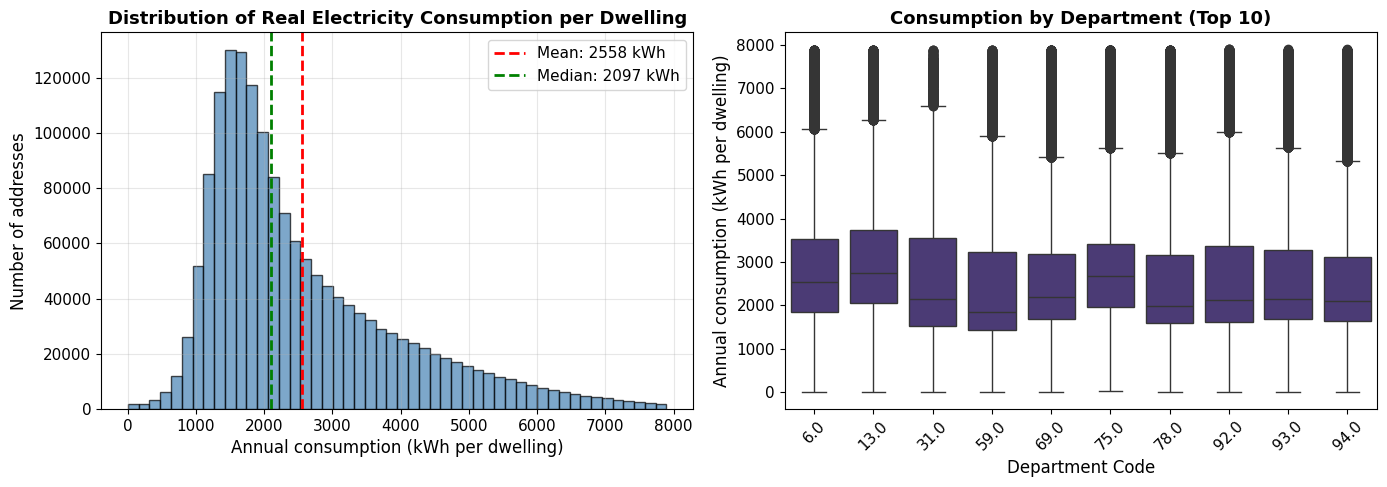

Chart saved as 'enedis_consumption_distribution.png'


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Histogram
axes[0].hist(enedis_clean['consumption_per_dwelling_kWh'], bins=50, 
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(enedis_clean['consumption_per_dwelling_kWh'].mean(), 
                color='red', linestyle='--', linewidth=2,
                label=f'Mean: {enedis_clean["consumption_per_dwelling_kWh"].mean():.0f} kWh')
axes[0].axvline(enedis_clean['consumption_per_dwelling_kWh'].median(), 
                color='green', linestyle='--', linewidth=2,
                label=f'Median: {enedis_clean["consumption_per_dwelling_kWh"].median():.0f} kWh')
axes[0].set_xlabel('Annual consumption (kWh per dwelling)', fontsize=12)
axes[0].set_ylabel('Number of addresses', fontsize=12)
axes[0].set_title('Distribution of Real Electricity Consumption per Dwelling', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Boxplot by department (top 10 departments)
top_departments = enedis_clean.groupby('department_code')['consumption_per_dwelling_kWh'].count().nlargest(10).index
top_data = enedis_clean[enedis_clean['department_code'].isin(top_departments)]

sns.boxplot(data=top_data, x='department_code', y='consumption_per_dwelling_kWh', ax=axes[1])
axes[1].set_xlabel('Department Code', fontsize=12)
axes[1].set_ylabel('Annual consumption (kWh per dwelling)', fontsize=12)
axes[1].set_title('Consumption by Department (Top 10)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('enedis_consumption_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as 'enedis_consumption_distribution.png'")

**Distribution of Real Electricity Consumption per Dwelling**

- This chart displays a highly right-skewed distribution, showing that the vast majority of French dwellings are concentrated at the lower end of the energy spectrum, typically consuming between 1,000 and 3,000 kWh per year.
- A significant gap is visible between the median of 2,097 kWh and the mean of 2,558 kWh, a classic indicator that the average is being pulled upward by extreme, high-consuming properties.
- Because of this heavy skewness caused by high-energy users, the median serves as a much more accurate and reliable metric to represent the true consumption of a typical household in this dataset.

**Consumption by Department (Top 10)**

- This boxplot demonstrates that the median annual electricity consumption remains remarkably stable across all ten departments, generally hovering within a narrow band between 1,800 and 2,800 kWh per dwelling.
- The most striking feature of this graph is the dense, heavy presence of outliers stretching up to 8,000 kWh across every single represented region.
- This high internal variation suggests that geographical location plays a minimal role in energy use; instead, specific building characteristics like insulation quality and individual occupant behaviors are the primary drivers of consumption.

## Save cleaned data

In [22]:
print("=" * 60)
print("SAVING CLEANED DATA")
print("=" * 60)

# Save as CSV
enedis_clean.to_csv('enedis_cleaned.csv', index=False)
print("Data saved as 'enedis_cleaned.csv'")

# Save as Parquet (faster and compressed)
try:
    enedis_clean.to_parquet('enedis_cleaned.parquet')
    print("Data saved as 'enedis_cleaned.parquet' (compressed format)")
except:
    print("Parquet not available, CSV only")

print(f"\nFinal dataset size: {len(enedis_clean):,} records")

SAVING CLEANED DATA


Data saved as 'enedis_cleaned.csv'


Data saved as 'enedis_cleaned.parquet' (compressed format)

Final dataset size: 1,609,179 records


## Summary Statistics Table

In [23]:
# Cell 7: Summary Statistics
print("=" * 60)
print("SUMMARY STATISTICS - ENEDIS DATASET")
print("=" * 60)

stats = enedis_df['consumption_per_dwelling_kWh'].describe()

print(f"Period: {enedis_df['year'].min()} - {enedis_df['year'].max()}")
print(f"Total sites: {len(enedis_df):,}")
print(f"Unique addresses: {enedis_df['address'].nunique():,}")
print(f"\nConsumption (kWh) per dwelling:")
print(stats)

SUMMARY STATISTICS - ENEDIS DATASET
Period: 2021 - 2024
Total sites: 1,625,434


Unique addresses: 374,103

Consumption (kWh) per dwelling:
count    1.625434e+06
mean     2.628728e+03
std      1.580040e+03
min      2.928571e+00
25%      1.549287e+03
50%      2.111700e+03
75%      3.300857e+03
max      3.075970e+04
Name: consumption_per_dwelling_kWh, dtype: float64


## Time Series Analysis - Evolution of consumption over time

TIME SERIES: CONSUMPTION EVOLUTION
 year  mean_kWh  median_kWh
 2021    2870.0      2255.0
 2022    2610.0      2109.0
 2023    2528.0      2044.0
 2024    2510.0      2049.0

📈 Year-over-year changes:
   2021.0 → 2022.0: Mean: -9.1% | Median: -6.5%
   2022.0 → 2023.0: Mean: -3.1% | Median: -3.1%
   2023.0 → 2024.0: Mean: -0.7% | Median: +0.2%

Highest consumption year: 2021 with 2870 kWh average
Overall trend: decreasing


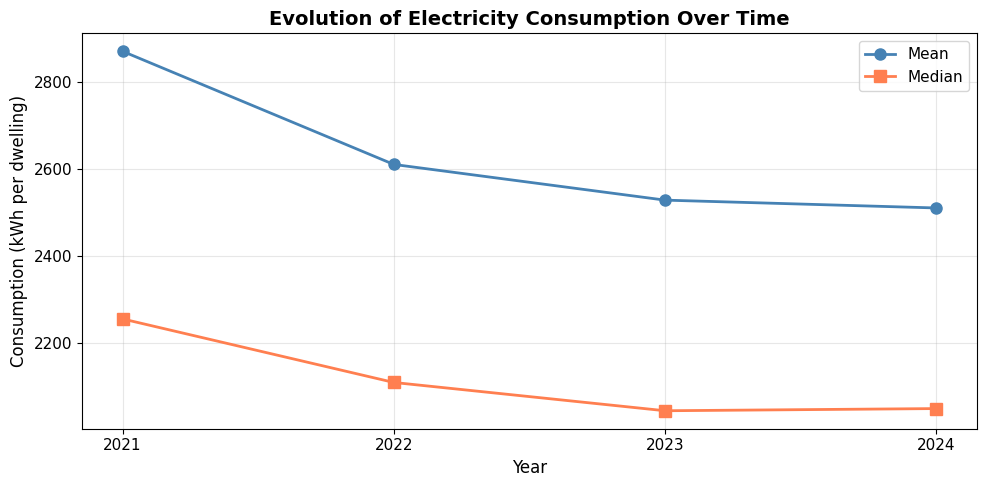


Chart saved as 'time_series.png'


In [25]:
# TIME SERIES ANALYSIS 
print("=" * 60)
print("TIME SERIES: CONSUMPTION EVOLUTION")
print("=" * 60)

# Group by year (mean and median)
yearly = enedis_df.groupby('year')['consumption_per_dwelling_kWh'].agg(['mean', 'median']).round(0).reset_index()
yearly.columns = ['year', 'mean_kWh', 'median_kWh']
print(yearly.to_string(index=False))

# Calculate year-over-year changes for mean
yearly['pct_change_mean'] = yearly['mean_kWh'].pct_change() * 100
yearly['pct_change_median'] = yearly['median_kWh'].pct_change() * 100

print("\n📈 Year-over-year changes:")
for i in range(1, len(yearly)):
    year = yearly.iloc[i]['year']
    change_mean = yearly.iloc[i]['pct_change_mean']
    change_median = yearly.iloc[i]['pct_change_median']
    prev_year = yearly.iloc[i-1]['year']
    print(f"   {prev_year} → {year}: Mean: {change_mean:+.1f}% | Median: {change_median:+.1f}%")

# Find highest consumption year
max_year = yearly.loc[yearly['mean_kWh'].idxmax(), 'year']
max_value = yearly['mean_kWh'].max()
print(f"\nHighest consumption year: {max_year} with {max_value:.0f} kWh average")

# Determine trend
first_year = yearly.iloc[0]['mean_kWh']
last_year = yearly.iloc[-1]['mean_kWh']
trend = "increasing" if last_year > first_year else "decreasing" if last_year < first_year else "stable"
print(f"Overall trend: {trend}")

# Line plot with Mean and Median
plt.figure(figsize=(10, 5))
plt.plot(yearly['year'], yearly['mean_kWh'], marker='o', linewidth=2, markersize=8, 
         color='steelblue', label='Mean')
plt.plot(yearly['year'], yearly['median_kWh'], marker='s', linewidth=2, markersize=8, 
         color='coral', label='Median')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Consumption (kWh per dwelling)', fontsize=12)
plt.title('Evolution of Electricity Consumption Over Time', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(yearly['year'])
plt.tight_layout()
plt.savefig('time_series.png', dpi=150)
plt.show()

print("\nChart saved as 'time_series.png'")

The observed trend in the Enedis dataset aligns perfectly with official French energy reports from 2024. The significant decrease in mean consumption between 2021 and 2022 (-9.1%) highlights a powerful combination of post-pandemic normalization, the onset of the European energy crisis, and the national sobriété énergétique awareness campaign. Furthermore, the slight stabilization and flattening of the curve in 2024 mirrors the national 1% rebound after two years of consecutive drops.

## Regional Analysis - Map of France * Energy Consumption

REGIONAL ANALYSIS: CONSUMPTION MAP OF FRANCE (STATIC)
geopandas already installed

Department statistics:
   Department with HIGHEST consumption: 84 (3212 kWh)
   Department with LOWEST consumption: 52 (1868 kWh)
   Consumption varies by factor of: 1.7x between regions

Loading France map data...


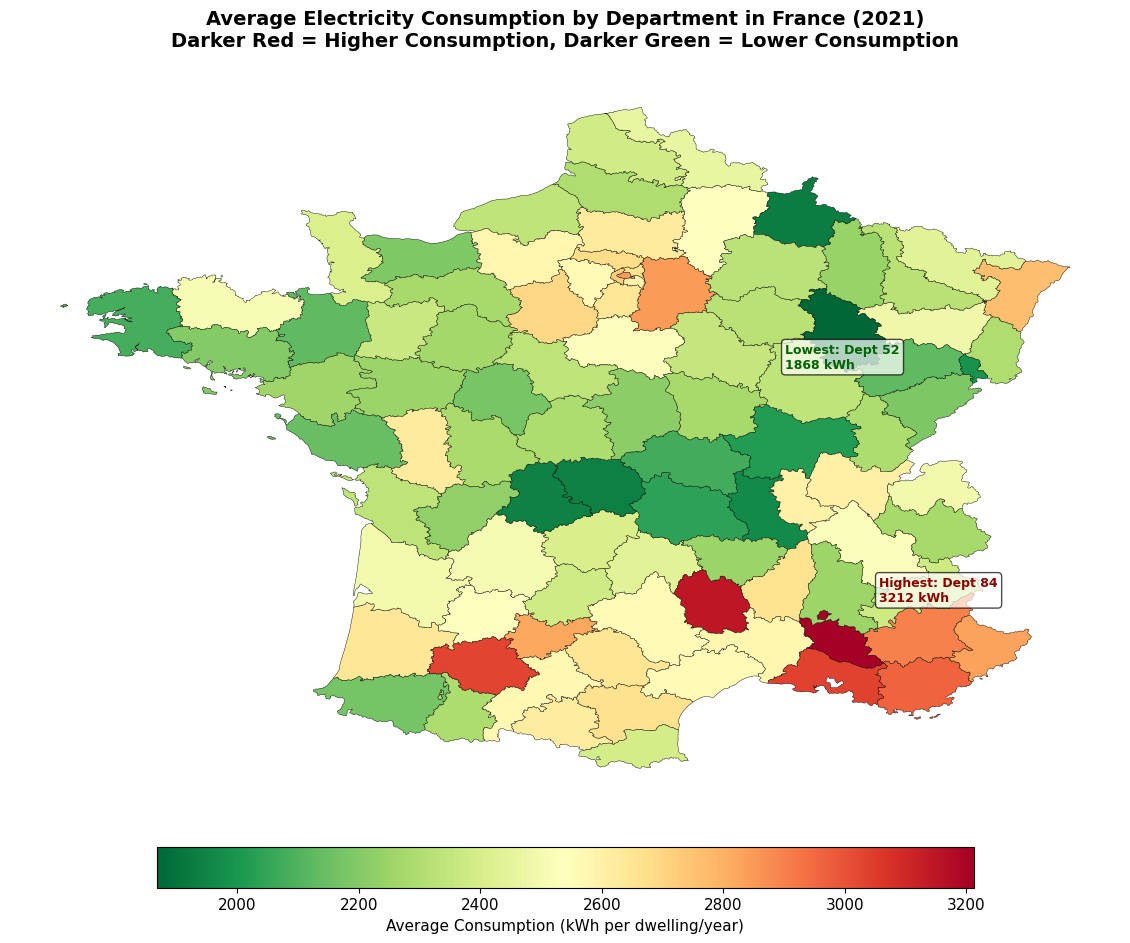


Map saved as 'france_consumption_map.png'

REGIONAL SUMMARY
HIGHEST consumption: Department 84 (3212 kWh/year)
LOWEST consumption: Department 52 (1868 kWh/year)
Regional variation factor: 1.7x

Interpretation: Dwellings in department 84 consume 1.7 times more
   electricity than those in department 52


In [27]:
print("=" * 60)
print("REGIONAL ANALYSIS: CONSUMPTION MAP OF FRANCE (STATIC)")
print("=" * 60)

# Install required packages (if needed)
import sys
import subprocess

try:
    import geopandas as gpd
    print("geopandas already installed")
except ImportError:
    print("Installing geopandas...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "geopandas", "-q"])
    import geopandas as gpd

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
from urllib.request import urlopen
import warnings
warnings.filterwarnings('ignore')

# Group by department (using department_code)
dept_stats = enedis_clean.groupby('department_code').agg({
    'consumption_per_dwelling_kWh': 'mean'
}).round(0)
dept_stats = dept_stats.reset_index()
dept_stats = dept_stats.dropna(subset=['department_code'])
dept_stats['department_code'] = dept_stats['department_code'].astype(int)

# Create department codes as strings with leading zeros (2 digits)
dept_stats['dept_code_str'] = dept_stats['department_code'].astype(str).str.zfill(2)

# Handle Corsica special codes (2A, 2B)
def convert_corsica(code):
    if code == '20':
        return '2A'  # Approximate for Corsica
    return code

dept_stats['dept_code_str'] = dept_stats['dept_code_str'].apply(convert_corsica)

# Find highest and lowest consuming departments
max_dept = dept_stats.loc[dept_stats['consumption_per_dwelling_kWh'].idxmax()]
min_dept = dept_stats.loc[dept_stats['consumption_per_dwelling_kWh'].idxmin()]
ratio = max_dept['consumption_per_dwelling_kWh'] / min_dept['consumption_per_dwelling_kWh']

print(f"\nDepartment statistics:")
print(f"   Department with HIGHEST consumption: {int(max_dept['department_code'])} ({max_dept['consumption_per_dwelling_kWh']:.0f} kWh)")
print(f"   Department with LOWEST consumption: {int(min_dept['department_code'])} ({min_dept['consumption_per_dwelling_kWh']:.0f} kWh)")
print(f"   Consumption varies by factor of: {ratio:.1f}x between regions")

# Load French departments geojson
print("\nLoading France map data...")
url = "https://france-geojson.gregoiredavid.fr/repo/departements.geojson"
with urlopen(url) as response:
    france_geo = json.load(response)

# Create GeoDataFrame
gdf = gpd.GeoDataFrame.from_features(france_geo['features'])

# Merge consumption data
gdf = gdf.merge(dept_stats, left_on='code', right_on='dept_code_str', how='left')

# Create the map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map with colors based on consumption
gdf.plot(column='consumption_per_dwelling_kWh',
         ax=ax,
         legend=True,
         cmap='RdYlGn_r',  # Red (high) to Green (low)
         edgecolor='black',
         linewidth=0.3,
         legend_kwds={
             'label': 'Average Consumption (kWh per dwelling/year)',
             'orientation': 'horizontal',
             'shrink': 0.7,
             'pad': 0.05
         })

# Remove axes
ax.set_axis_off()

# Add title
ax.set_title('Average Electricity Consumption by Department in France (2021)\nDarker Red = Higher Consumption, Darker Green = Lower Consumption',
             fontsize=14, fontweight='bold', pad=20)

# Add annotations for highest and lowest departments
# Highest consumption department
if max_dept['dept_code_str'] in gdf['code'].values:
    highest_geom = gdf[gdf['code'] == max_dept['dept_code_str']].geometry
    if len(highest_geom) > 0:
        bounds = highest_geom.total_bounds
        center_x = (bounds[0] + bounds[2]) / 2
        center_y = (bounds[1] + bounds[3]) / 2
        ax.annotate(f"Highest: Dept {int(max_dept['department_code'])}\n{max_dept['consumption_per_dwelling_kWh']:.0f} kWh",
                    xy=(center_x, center_y), xytext=(center_x + 0.5, center_y + 0.5),
                    fontsize=9, fontweight='bold', color='darkred',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

# Lowest consumption department
if min_dept['dept_code_str'] in gdf['code'].values:
    lowest_geom = gdf[gdf['code'] == min_dept['dept_code_str']].geometry
    if len(lowest_geom) > 0:
        bounds = lowest_geom.total_bounds
        center_x = (bounds[0] + bounds[2]) / 2
        center_y = (bounds[1] + bounds[3]) / 2
        ax.annotate(f"Lowest: Dept {int(min_dept['department_code'])}\n{min_dept['consumption_per_dwelling_kWh']:.0f} kWh",
                    xy=(center_x, center_y), xytext=(center_x - 0.8, center_y - 0.5),
                    fontsize=9, fontweight='bold', color='darkgreen',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('france_consumption_map.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("\nMap saved as 'france_consumption_map.png'")

# Print final summary
print("\n" + "=" * 60)
print("REGIONAL SUMMARY")
print("=" * 60)
print(f"HIGHEST consumption: Department {int(max_dept['department_code'])} ({max_dept['consumption_per_dwelling_kWh']:.0f} kWh/year)")
print(f"LOWEST consumption: Department {int(min_dept['department_code'])} ({min_dept['consumption_per_dwelling_kWh']:.0f} kWh/year)")
print(f"Regional variation factor: {ratio:.1f}x")
print(f"\nInterpretation: Dwellings in department {int(max_dept['department_code'])} consume {ratio:.1f} times more")
print(f"   electricity than those in department {int(min_dept['department_code'])}")

At first glance, the geographical distribution presents a counterintuitive result: major urban centers like Paris (75) appear green (low electricity consumption), while rural or southern departments like Vaucluse (84) exhibit the highest averages. This phenomenon is explained by several structural factors. First, large metropolitan areas have a high density of multi-family apartment buildings, which benefit from shared-wall thermal insulation and predominantly rely on city gas networks or collective district heating rather than electricity. Second, rural departments have a higher proportion of single-family detached homes with larger floor areas and electric heating. Third, the high consumption in southern departments is strongly driven by the widespread adoption of residential air conditioning to combat rising summer temperatures, establishing cooling as a major driver of French residential electricity demand.

## Import DPE data from ADEME

In [28]:
print("=" * 60)
print("LOADING DPE_SHORT2.CSV - ALL COLUMNS (UP TO ROW 1,051,034)")
print("=" * 60)

# Because the file is too large we will use 1,051,034. Error loading 1,051,035
problem_row = 1051035
rows_to_load = problem_row - 1  # Subtract 1 for header

print(f"Loading first {rows_to_load:,} rows (avoiding problem at row {problem_row})")
print("Loading ALL available columns...")

try:
    # Load ALL columns without filtering
    dpe_df = pd.read_csv('DPE_short2.csv',
                          nrows=rows_to_load,
                          low_memory=False,
                          on_bad_lines='skip')
    
    print(f"\nLOADED {len(dpe_df):,} DPE RECORDS")
    print(f"Total columns loaded: {len(dpe_df.columns)}")
    print(f"Memory usage: {dpe_df.memory_usage(deep=True).sum() / (1024**2):.1f} MB")
    
    print(f"\nALL COLUMN NAMES (original French):")
    for i, col in enumerate(dpe_df.columns, 1):
        print(f"   {i:3}. {col}")
    
except Exception as e:
    print(f"Error: {e}")

LOADING DPE_SHORT2.CSV - ALL COLUMNS (UP TO ROW 1,051,034)
Loading first 1,051,034 rows (avoiding problem at row 1051035)
Loading ALL available columns...



LOADED 1,051,034 DPE RECORDS
Total columns loaded: 28


Memory usage: 743.3 MB

ALL COLUMN NAMES (original French):
     1. etiquette_dpe
     2. type_batiment
     3. periode_construction
     4. surface_habitable_logement
     5. adresse_ban
     6. code_postal_ban
     7. code_departement_ban
     8. code_region_ban
     9. code_insee_ban
    10. conso_5 usages_ef
    11. conso_5 usages_par_m2_ef
    12. conso_chauffage_ef
    13. conso_ecs_ef
    14. conso_refroidissement_ef
    15. conso_eclairage_ef
    16. conso_auxiliaires_ef
    17. cout_total_5_usages
    18. cout_chauffage
    19. cout_ecs
    20. cout_refroidissement
    21. cout_eclairage
    22. cout_auxiliaires
    23. annee_construction
    24. type_energie_principale_chauffage
    25. qualite_isolation_enveloppe
    26. zone_climatique
    27. etiquette_ges
    28. emission_ges_5_usages


In [29]:
# Rename ALL columns to English
print("=" * 60)
print("RENAMING ALL COLUMNS TO ENGLISH")
print("=" * 60)

translation_dict = {
    # Energy ratings
    'etiquette_dpe': 'DPE_class',
    'etiquette_ges': 'GHG_class',
    
    # Building characteristics
    'type_batiment': 'building_type',
    'periode_construction': 'construction_period',
    'surface_habitable_logement': 'surface_m2',
    'annee_construction': 'construction_year',
    
    # Address & location
    'adresse_ban': 'address',
    'code_postal_ban': 'postal_code',
    'code_departement_ban': 'department_code',
    'code_region_ban': 'region_code',
    'code_insee_ban': 'insee_code',
    
    # Energy consumption - Final Energy (EF)
    'conso_5 usages_ef': 'total_consumption_kWh',
    'conso_5 usages_par_m2_ef': 'consumption_per_m2_kWh',
    'conso_chauffage_ef': 'heating_kWh',
    'conso_ecs_ef': 'hot_water_kWh',
    'conso_refroidissement_ef': 'cooling_kWh',
    'conso_eclairage_ef': 'lighting_kWh',
    'conso_auxiliaires_ef': 'auxiliaries_kWh',
    
    # Costs (Euros)
    'cout_total_5_usages': 'total_cost_euros',
    'cout_chauffage': 'heating_cost_euros',
    'cout_ecs': 'hot_water_cost_euros',
    'cout_refroidissement': 'cooling_cost_euros',
    'cout_eclairage': 'lighting_cost_euros',
    'cout_auxiliaires': 'auxiliaries_cost_euros',
    
    # Heating & insulation
    'type_energie_principale_chauffage': 'main_heating_energy',
    'qualite_isolation_enveloppe': 'insulation_quality',
    
    # Climate & emissions
    'zone_climatique': 'climate_zone',
    'emission_ges_5_usages': 'total_ghg_emissions'
}

# Apply renaming
dpe_df = dpe_df.rename(columns=translation_dict)

print(f"Renamed {len(translation_dict)} columns to English")
print(f"\nCOLUMNS NOW IN ENGLISH ({len(dpe_df.columns)} columns):")
for i, col in enumerate(dpe_df.columns, 1):
    print(f"   {i:2}. {col}")

RENAMING ALL COLUMNS TO ENGLISH
Renamed 28 columns to English

COLUMNS NOW IN ENGLISH (28 columns):
    1. DPE_class
    2. building_type
    3. construction_period
    4. surface_m2
    5. address
    6. postal_code
    7. department_code
    8. region_code
    9. insee_code
   10. total_consumption_kWh
   11. consumption_per_m2_kWh
   12. heating_kWh
   13. hot_water_kWh
   14. cooling_kWh
   15. lighting_kWh
   16. auxiliaries_kWh
   17. total_cost_euros
   18. heating_cost_euros
   19. hot_water_cost_euros
   20. cooling_cost_euros
   21. lighting_cost_euros
   22. auxiliaries_cost_euros
   23. construction_year
   24. main_heating_energy
   25. insulation_quality
   26. climate_zone
   27. GHG_class
   28. total_ghg_emissions


In [30]:
# Clean and filter data
print("=" * 60)
print("DATA CLEANING AND FILTERING")
print("=" * 60)

initial_count = len(dpe_df)
print(f"Initial records: {initial_count:,}")

# Remove rows with missing DPE class
dpe_df = dpe_df.dropna(subset=['DPE_class'])
print(f"After removing null DPE class: {len(dpe_df):,} (removed {initial_count - len(dpe_df):,})")

# Remove unrealistic consumption values (500 to 50,000 kWh) - OUTLIERS
if 'total_consumption_kWh' in dpe_df.columns:
    dpe_df = dpe_df[(dpe_df['total_consumption_kWh'] >= 500) & (dpe_df['total_consumption_kWh'] <= 50000)]
    print(f"After filtering consumption (500-50,000 kWh): {len(dpe_df):,}")

print(f"\nFINAL CLEAN DATASET: {len(dpe_df):,} records")

DATA CLEANING AND FILTERING
Initial records: 1,051,034


After removing null DPE class: 1,051,034 (removed 0)


After filtering consumption (500-50,000 kWh): 1,025,599

FINAL CLEAN DATASET: 1,025,599 records


## Save complete cleaned dataset


In [31]:
print("=" * 60)
print("SAVING COMPLETE CLEANED DATASET")
print("=" * 60)

# Save as CSV
dpe_df.to_csv('dpe_complete_cleaned.csv', index=False)
print(f"Saved 'dpe_complete_cleaned.csv' with {len(dpe_df):,} records and {len(dpe_df.columns)} columns")

# Also save as Parquet (faster, compressed)
try:
    dpe_df.to_parquet('dpe_complete_cleaned.parquet')
    print(f"Saved 'dpe_complete_cleaned.parquet' (compressed format)")
except:
    print("Parquet not available")

print(f"\nFinal dataset info:")
print(f"   Records: {len(dpe_df):,}")
print(f"   Columns: {len(dpe_df.columns)}")
print(f"   Memory: {dpe_df.memory_usage(deep=True).sum() / (1024**2):.1f} MB")

SAVING COMPLETE CLEANED DATASET


Saved 'dpe_complete_cleaned.csv' with 1,025,599 records and 28 columns


Saved 'dpe_complete_cleaned.parquet' (compressed format)

Final dataset info:
   Records: 1,025,599
   Columns: 28


   Memory: 759.9 MB


## DPE National Distribution - Pie Chart

DPE NATIONAL DISTRIBUTION - PIE CHART


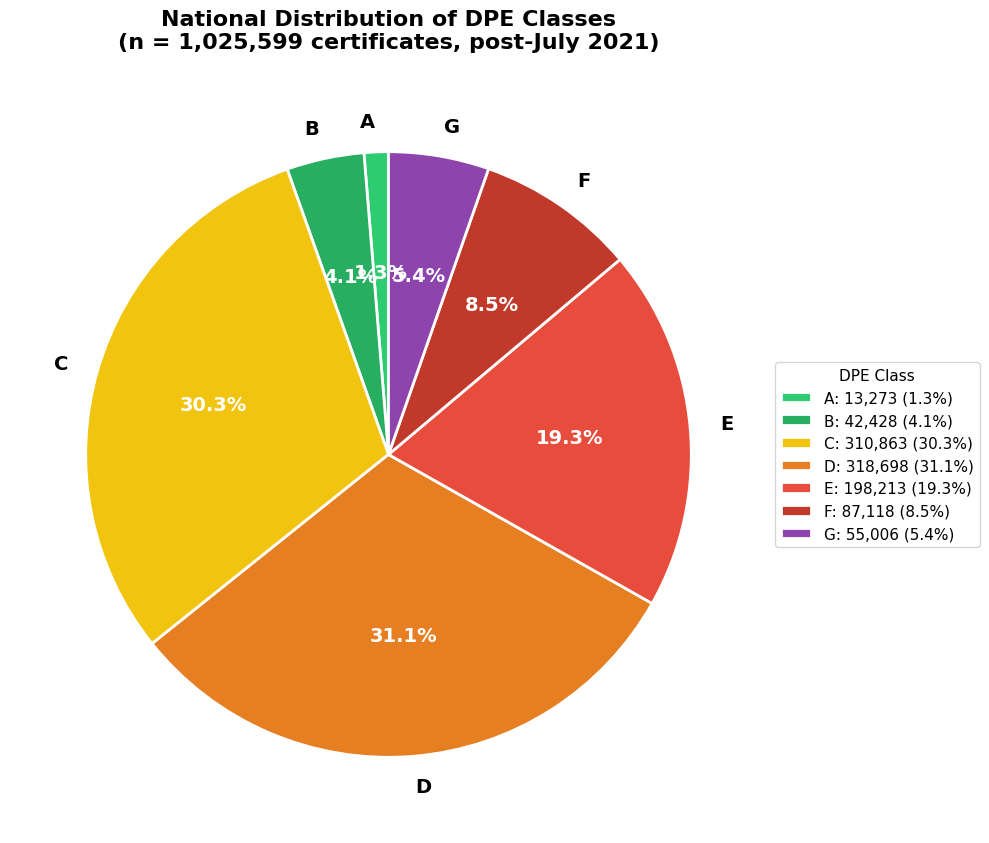


Chart saved as 'dpe_national_distribution_pie.png'

Distribution summary:
   Class A: 13,273 (1.3%)
   Class B: 42,428 (4.1%)
   Class C: 310,863 (30.3%)
   Class D: 318,698 (31.1%)
   Class E: 198,213 (19.3%)
   Class F: 87,118 (8.5%)
   Class G: 55,006 (5.4%)


In [32]:
# Visualization
print("=" * 60)
print("DPE NATIONAL DISTRIBUTION - PIE CHART")
print("=" * 60)

# Get DPE class distribution
class_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
class_counts = dpe_df['DPE_class'].value_counts().reindex(class_order).fillna(0)
total = class_counts.sum()
percentages = (class_counts / total * 100).round(1)

# Colors for each class (green to red/purple)
colors = {
    'A': '#2ecc71',   # bright green
    'B': '#27ae60',   # green
    'C': '#f1c40f',   # yellow
    'D': '#e67e22',   # orange
    'E': '#e74c3c',   # red
    'F': '#c0392b',   # dark red
    'G': '#8e44ad'    # purple
}

color_list = [colors[cls] for cls in class_order]

# Create figure
fig, ax = plt.subplots(figsize=(10, 10))

# Create pie chart
wedges, texts, autotexts = ax.pie(class_counts.values,
                                    labels=class_order,
                                    autopct='%1.1f%%',
                                    colors=color_list,
                                    startangle=90,
                                    textprops={'fontsize': 14, 'fontweight': 'bold'},
                                    wedgeprops={'edgecolor': 'white', 'linewidth': 2})

# Customize percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

# Add title
ax.set_title(f'National Distribution of DPE Classes\n(n = {total:,} certificates, post-July 2021)', 
             fontsize=16, fontweight='bold', pad=20)

# Add legend with counts
legend_labels = [f'{cls}: {int(class_counts[cls]):,} ({percentages[cls]:.1f}%)' 
                 for cls in class_order if class_counts[cls] > 0]
ax.legend(wedges, legend_labels, title="DPE Class", 
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=11)

plt.tight_layout()
plt.savefig('dpe_national_distribution_pie.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("\nChart saved as 'dpe_national_distribution_pie.png'")
print("\nDistribution summary:")
for cls in class_order:
    if class_counts[cls] > 0:
        print(f"   Class {cls}: {class_counts[cls]:,} ({percentages[cls]:.1f}%)")

The pie chart showcases a classic Gaussian-like distribution that is highly representative of the post-July 2021 French building stock. The vast majority of the certificates are concentrated in the mid-tier categories, with classes C, D, and E accounting for over 80% of the sample. Conversely, ultra-efficient dwellings (Classes A and B) remain exceptional at a combined 5.4%. The energy-inefficient properties (passoires énergétiques, Classes F and G) represent 13.9% of the certificates.